# Step 1 — Generate the Review Dataset

**Project:** Customer Review Intelligence — NLP-Powered Product & Reputation Analytics

This notebook generates a realistic, Amazon-style product review dataset and saves it
directly into your project folder:

`C:\Users\Prashma\Desktop\Resume Projects\Data Analytics\NLP-powered customer review analytics system\data\raw\`

> **Note:** Kaggle/Hugging Face weren't reachable from the build sandbox, so this is a
> structurally realistic synthetic dataset (same schema as the popular Kaggle "Amazon
> Product Reviews" sets). If you later download the real Kaggle CSV, just save it as
> `amazon_reviews.csv` in the same `data\raw\` folder with the same columns, and every
> downstream notebook works unchanged — no code edits needed.

**Before running:** make sure this notebook lives anywhere you like — the path used to
save files is hardcoded below, so it doesn't matter where you launch Jupyter from.


In [1]:
"""
generate_dataset.py
--------------------
Generates a realistic, Amazon-style product review dataset for the
Customer Review Intelligence project.

Why synthetic data?
Kaggle/Hugging Face are not reachable from this build environment, so this
script produces a structurally realistic stand-in: same schema as the
popular Kaggle "Amazon Product Reviews" datasets, believable review text
built from real complaint/praise language patterns, realistic rating
distributions per product (some genuinely good products, some genuinely
bad ones, some mixed/declining), and a 14-month date range so sentiment
trend analysis has something real to show.

To swap in real Kaggle data later: save it as
data/raw/amazon_reviews.csv with at least these columns:
    review_id, product_id, product_name, category, rating,
    review_title, review_text, review_date, verified_purchase
...and every downstream script will work unchanged.
"""

import random
import uuid
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd

random.seed(42)
np.random.seed(42)

# ---------------------------------------------------------------------
# PROJECT ROOT — all paths in this project are anchored here.
# Change this ONE line if you ever move the project folder.
# ---------------------------------------------------------------------
BASE_DIR = Path(r"C:\Users\Prashma\Desktop\Resume Projects\Data Analytics\NLP-powered customer review analytics system")
RAW_DIR = BASE_DIR / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# 1. Product catalog: categories, products, and an underlying "quality"
#    score per product that drives its rating distribution. Some
#    products are seeded to *decline* over time (for the risk-scoring
#    step to catch), most stay stable.
# ---------------------------------------------------------------------

CATEGORIES = {
    "Electronics": [
        "Wireless Bluetooth Earbuds", "Portable Power Bank 20000mAh",
        "USB-C Fast Charger", "Noise Cancelling Headphones",
        "Smart Fitness Tracker", "4K Streaming Media Player",
        "Wireless Phone Charger Stand", "Bluetooth Speaker Mini",
    ],
    "Kitchen": [
        "Stainless Steel Air Fryer", "Electric Kettle 1.7L",
        "Non-Stick Frying Pan Set", "Stand Mixer 5-Quart",
        "Cold Brew Coffee Maker", "Vacuum Sealer Food Storage",
        "Digital Kitchen Scale", "Ceramic Knife Set",
    ],
    "Home & Office": [
        "Ergonomic Office Chair", "Adjustable Standing Desk",
        "LED Desk Lamp with USB Port", "Memory Foam Seat Cushion",
        "Under-Desk Cable Management Tray", "Wireless Mouse and Keyboard Combo",
    ],
    "Baby & Kids": [
        "Convertible Baby Car Seat", "Silicone Baby Feeding Set",
        "Baby Monitor with Camera", "Toddler Balance Bike",
    ],
    "Health & Personal Care": [
        "Electric Toothbrush Set", "Facial Cleansing Brush",
        "Digital Body Weight Scale", "Handheld Massage Gun",
        "Blue Light Blocking Glasses",
    ],
    "Pet Supplies": [
        "Automatic Pet Food Dispenser", "Orthopedic Dog Bed",
        "Cat Water Fountain", "Retractable Dog Leash",
    ],
}

# Underlying quality tiers (drives rating distribution):
#   "excellent"  -> mostly 4-5 star, stable
#   "good"       -> mostly 4 star, a few 2-3 star, stable
#   "mixed"      -> spread across the board, stable
#   "declining"  -> starts good, gets worse over the date range (AT RISK)
#   "poor"       -> mostly 1-2 star, stable (already bad, low volume)
QUALITY_WEIGHTS = {
    "excellent": 0.28,
    "good": 0.32,
    "mixed": 0.18,
    "declining": 0.14,
    "poor": 0.08,
}

# ---------------------------------------------------------------------
# 2. Review text building blocks, organized by sentiment and theme.
#    Real complaint/praise clusters that topic modeling should surface.
# ---------------------------------------------------------------------

POSITIVE_SNIPPETS = {
    "quality": [
        "Build quality is excellent, feels really sturdy and well made.",
        "The materials feel premium, way better than I expected for the price.",
        "Solid construction, doesn't feel cheap at all.",
        "Really impressed with the craftsmanship on this one.",
    ],
    "value": [
        "Great value for the money, honestly exceeded my expectations.",
        "Worth every penny, I'd buy this again in a heartbeat.",
        "Cheaper than similar products but performs just as well.",
    ],
    "shipping": [
        "Arrived earlier than expected and packaging was excellent.",
        "Fast shipping, item arrived in perfect condition.",
        "Delivery was quick and the box was well protected.",
    ],
    "ease_of_use": [
        "Super easy to set up, took less than five minutes.",
        "Intuitive to use right out of the box, no manual needed.",
        "Setup was a breeze, even for someone not very technical.",
    ],
    "performance": [
        "Works exactly as described, no issues so far after weeks of use.",
        "Performance has been consistent and reliable every single day.",
        "Does exactly what it promises, no complaints at all.",
    ],
    "customer_service": [
        "Customer service was incredibly responsive when I had a question.",
        "The seller resolved my issue quickly and professionally.",
    ],
    "design": [
        "Love the sleek design, looks great on my desk.",
        "Compact and stylish, fits perfectly in my space.",
    ],
}

NEGATIVE_SNIPPETS = {
    "quality": [
        "Feels really cheap and flimsy, broke within the first week.",
        "Build quality is poor, plastic parts feel like they'll snap.",
        "Fell apart after minimal use, very disappointed in the construction.",
        "The stitching came undone after just a few uses.",
    ],
    "shipping": [
        "Package arrived late, well past the estimated delivery window.",
        "Item showed up in a damaged box and the product was dented.",
        "Delivery took almost three weeks, way longer than promised.",
        "Packaging was flimsy and the product was scratched on arrival.",
    ],
    "sizing": [
        "Runs much smaller than the size chart suggests.",
        "Sizing is way off from what's listed, had to return it.",
    ],
    "defective": [
        "Stopped working after only three days of normal use.",
        "Arrived completely dead on arrival, wouldn't turn on at all.",
        "Battery stopped holding a charge after less than two weeks.",
        "Malfunctioned right out of the box, had to request a replacement.",
    ],
    "value": [
        "Way overpriced for what you actually get in the box.",
        "Not worth the money, you can find better quality for less.",
    ],
    "customer_service": [
        "Reached out to customer support and never got a response.",
        "Return process was a nightmare and support was unhelpful.",
    ],
    "instructions": [
        "Instructions were confusing and missing key steps.",
        "No manual included, had to figure out setup myself.",
    ],
    "smell_noise": [
        "Makes a really loud, annoying noise during operation.",
        "Had a strong chemical smell straight out of the packaging.",
    ],
}

NEUTRAL_SNIPPETS = [
    "It's okay, does the job but nothing special.",
    "Average product, meets basic expectations and that's about it.",
    "Not bad, not great, pretty much what I expected for this price range.",
    "Decent enough for occasional use, wouldn't say it's outstanding.",
    "It works fine so far, will update this review after more time using it.",
]

OPENERS = ["", "Honestly, ", "So, ", "Overall, ", "To be fair, ", "In short, "]


def _pick(d):
    theme = random.choice(list(d.keys()))
    return theme, random.choice(d[theme])


def build_review_text(sentiment: str, n_sentences: int = 2):
    """Builds a multi-sentence review + returns the dominant theme tag."""
    sentences = []
    themes = []
    if sentiment == "positive":
        for _ in range(n_sentences):
            theme, s = _pick(POSITIVE_SNIPPETS)
            sentences.append(s)
            themes.append(theme)
    elif sentiment == "negative":
        for _ in range(n_sentences):
            theme, s = _pick(NEGATIVE_SNIPPETS)
            sentences.append(s)
            themes.append(theme)
    else:
        sentences.append(random.choice(NEUTRAL_SNIPPETS))
        themes.append("general")

    text = random.choice(OPENERS) + " ".join(sentences)
    return text.strip(), themes[0]


def rating_from_sentiment(sentiment: str):
    if sentiment == "positive":
        return np.random.choice([4, 5], p=[0.35, 0.65])
    elif sentiment == "negative":
        return np.random.choice([1, 2], p=[0.55, 0.45])
    else:
        return np.random.choice([2, 3, 4], p=[0.15, 0.65, 0.20])


def sentiment_for_quality(quality: str, progress: float):
    """
    progress: 0.0 (start of date range) -> 1.0 (end of date range)
    Returns 'positive' / 'neutral' / 'negative' probabilistically,
    based on product quality tier. 'declining' products get worse
    as progress increases (this is what the risk-scoring step should catch).
    """
    if quality == "excellent":
        p = [0.82, 0.13, 0.05]
    elif quality == "good":
        p = [0.65, 0.22, 0.13]
    elif quality == "mixed":
        p = [0.40, 0.30, 0.30]
    elif quality == "poor":
        p = [0.12, 0.18, 0.70]
    elif quality == "declining":
        # starts like a "good" product, ends like a "poor" one
        start = np.array([0.68, 0.20, 0.12])
        end = np.array([0.18, 0.22, 0.60])
        p = start + (end - start) * progress
        p = p / p.sum()
    else:
        p = [0.5, 0.3, 0.2]
    return np.random.choice(["positive", "neutral", "negative"], p=p)


# ---------------------------------------------------------------------
# 3. Build product catalog with assigned quality tiers
# ---------------------------------------------------------------------

def build_catalog():
    products = []
    pid = 1000
    tiers = list(QUALITY_WEIGHTS.keys())
    weights = list(QUALITY_WEIGHTS.values())
    for category, names in CATEGORIES.items():
        for name in names:
            quality = np.random.choice(tiers, p=weights)
            products.append({
                "product_id": f"P{pid}",
                "product_name": name,
                "category": category,
                "quality_tier": quality,  # kept out of final public CSV; used only to generate data
            })
            pid += 1
    return pd.DataFrame(products)


# ---------------------------------------------------------------------
# 4. Generate reviews across a 14-month window
# ---------------------------------------------------------------------

def generate_reviews(catalog: pd.DataFrame, n_reviews: int = 6000):
    start_date = datetime(2024, 6, 1)
    end_date = datetime(2025, 8, 31)
    total_days = (end_date - start_date).days

    reviewer_names = [f"Reviewer{i}" for i in range(1, 3000)]

    rows = []
    # weight review volume per product (some products just get reviewed more)
    volume_weights = np.random.dirichlet(np.ones(len(catalog)) * 1.5)

    for _, prod in catalog.iterrows():
        pass  # volume assigned below via sampling

    product_choices = np.random.choice(
        catalog.index, size=n_reviews, p=volume_weights
    )

    for idx in product_choices:
        prod = catalog.loc[idx]
        day_offset = int(np.random.beta(2, 1.8) * total_days)  # slightly more recent-weighted
        review_date = start_date + timedelta(days=day_offset)
        progress = day_offset / total_days

        sentiment = sentiment_for_quality(prod["quality_tier"], progress)
        rating = int(rating_from_sentiment(sentiment))
        n_sent = random.choice([1, 1, 2, 2, 3])
        text, theme = build_review_text(sentiment, n_sent)

        title_map = {
            "positive": ["Great purchase!", "Highly recommend", "Very happy with this",
                         "Works great", "Exceeded expectations"],
            "negative": ["Disappointed", "Would not recommend", "Not what I expected",
                         "Had issues with this", "Wouldn't buy again"],
            "neutral": ["It's okay", "Does the job", "Average", "Mixed feelings"],
        }

        rows.append({
            "review_id": str(uuid.uuid4())[:8],
            "product_id": prod["product_id"],
            "product_name": prod["product_name"],
            "category": prod["category"],
            "rating": rating,
            "review_title": random.choice(title_map[sentiment]),
            "review_text": text,
            "review_date": review_date.strftime("%Y-%m-%d"),
            "reviewer_name": random.choice(reviewer_names),
            "verified_purchase": np.random.choice([True, False], p=[0.85, 0.15]),
            "helpful_votes": int(np.random.exponential(2)),
            "_true_theme": theme,          # kept for internal validation only
            "_true_sentiment": sentiment,  # kept for internal validation only
        })

    df = pd.DataFrame(rows).sort_values("review_date").reset_index(drop=True)
    return df


if __name__ == "__main__":
    catalog = build_catalog()
    reviews = generate_reviews(catalog, n_reviews=6500)

    # Public-facing files (no "ground truth" columns — the pipeline has to
    # actually discover sentiment/themes, same as with real data)
    public_reviews = reviews.drop(columns=["_true_theme", "_true_sentiment"])
    public_catalog = catalog.drop(columns=["quality_tier"])

    public_reviews.to_csv(RAW_DIR / "amazon_reviews.csv", index=False)
    public_catalog.to_csv(RAW_DIR / "product_catalog.csv", index=False)

    # Internal validation copy (so we can sanity-check the pipeline later)
    reviews.to_csv(RAW_DIR / "_reviews_with_ground_truth.csv", index=False)
    catalog.to_csv(RAW_DIR / "_catalog_with_quality.csv", index=False)

    print(f"\nFiles saved to: {RAW_DIR}")

    print(f"Generated {len(public_reviews)} reviews across {len(public_catalog)} products.")
    print(public_reviews.head())
    print("\nRating distribution:")
    print(public_reviews["rating"].value_counts(normalize=True).sort_index())



Files saved to: C:\Users\Prashma\Desktop\Resume Projects\Data Analytics\NLP-powered customer review analytics system\data\raw
Generated 6500 reviews across 35 products.
  review_id product_id                  product_name      category  rating  \
0  bdfe999f      P1009          Electric Kettle 1.7L       Kitchen       3   
1  4ed33c3f      P1010      Non-Stick Frying Pan Set       Kitchen       5   
2  3c5be57f      P1006  Wireless Phone Charger Stand   Electronics       5   
3  3f6ffd34      P1032            Orthopedic Dog Bed  Pet Supplies       4   
4  1a0b62ed      P1032            Orthopedic Dog Bed  Pet Supplies       5   

            review_title                                        review_text  \
0                Average  So, It works fine so far, will update this rev...   
1   Very happy with this  Works exactly as described, no issues so far a...   
2            Works great  Overall, Setup was a breeze, even for someone ...   
3  Exceeded expectations  So, Intuitive to us

## Quick look at the data

In [2]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"C:\Users\Prashma\Desktop\Resume Projects\Data Analytics\NLP-powered customer review analytics system")
df = pd.read_csv(BASE_DIR / "data" / "raw" / "amazon_reviews.csv")
print(f"{len(df)} reviews across {df['product_id'].nunique()} products")
df.head()

6500 reviews across 35 products


,review_id,product_id,product_name,category,rating,review_title,review_text,review_date,reviewer_name,verified_purchase,helpful_votes
0,bdfe999f,P1009,Electric Kettle 1.7L,Kitchen,3,Average,"So, It works fine so far, will update this rev...",2024-06-06,Reviewer421,True,1
1,4ed33c3f,P1010,Non-Stick Frying Pan Set,Kitchen,5,Very happy with this,"Works exactly as described, no issues so far a...",2024-06-07,Reviewer2629,True,0
2,3c5be57f,P1006,Wireless Phone Charger Stand,Electronics,5,Works great,"Overall, Setup was a breeze, even for someone ...",2024-06-08,Reviewer1024,True,2
3,3f6ffd34,P1032,Orthopedic Dog Bed,Pet Supplies,4,Exceeded expectations,"So, Intuitive to use right out of the box, no ...",2024-06-08,Reviewer910,False,0
4,1a0b62ed,P1032,Orthopedic Dog Bed,Pet Supplies,5,Great purchase!,"Super easy to set up, took less than five minu...",2024-06-09,Reviewer2307,True,2


<Axes: title={'center': 'Rating distribution'}, xlabel='rating'>

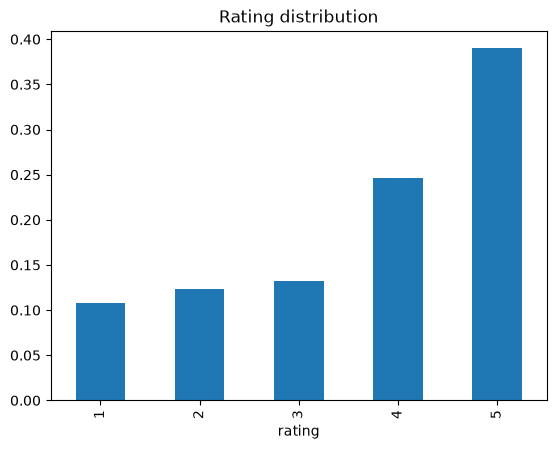

In [3]:
df['rating'].value_counts(normalize=True).sort_index().plot(kind='bar', title='Rating distribution')